In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os
import matplotlib as mpl
import matplotlib.font_manager as fm
from scipy import stats

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df= pd.read_csv(r'/Users/gggyyu/Desktop/(아이엠뱅크) 2025 교육용 데이터/(아이엠뱅크) 2025 교육용 데이터.csv', encoding='cp949')
df_b = pd.read_csv(r"/Users/gggyyu/im_bank/project_1/iM뱅크_금리현황_2022-2024.csv")
fee_df = pd.read_csv(r'/Users/gggyyu/im_bank/project_1/추정비이자수익률.csv')

#df_c = pd.read_csv(r'C:\Projects\bda_exam\(아이엠뱅크) 2025 교육용 데이터\iM뱅크_금리현황_2022-2024(post).csv')

In [4]:
font_file_candidates = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
]
selected_font_file = next((font for font in font_file_candidates if os.path.exists(font)), None)
font_name = None
if selected_font_file is not None:
    try:
        fm.fontManager.addfont(selected_font_file)
    except Exception:
        pass
    font_name = fm.FontProperties(fname=selected_font_file).get_name()
    print(f'사용 폰트 파일: {selected_font_file}')
    print(f'적용 폰트 이름: {font_name}')
else:
    print('사용 가능한 한글 폰트 파일을 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')

# seaborn보다 먼저 matplotlib 기본 폰트를 고정합니다.
if font_name is not None:
    mpl.rcParams.update({
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
        'svg.fonttype': 'none'
    })

sns.set_theme(
    style='whitegrid',
    rc={
        'font.family': font_name if font_name is not None else 'sans-serif',
        'font.sans-serif': [font_name] if font_name is not None else ['DejaVu Sans'],
        'axes.unicode_minus': False
    }
)

if font_name is not None:
    plt.rcParams['font.family'] = font_name
    plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('현재 matplotlib font.family:', mpl.rcParams['font.family'])
print('현재 matplotlib font.sans-serif:', mpl.rcParams['font.sans-serif'])




사용 폰트 파일: /System/Library/Fonts/AppleSDGothicNeo.ttc
적용 폰트 이름: Apple SD Gothic Neo
현재 matplotlib font.family: ['Apple SD Gothic Neo']
현재 matplotlib font.sans-serif: ['Apple SD Gothic Neo']


In [5]:
count_mapping = {
    "0건": 0,
    "1건": 1,
    "2건": 2,
    "2건초과 5건이하": 3.5,
    "5건초과 10건이하": 7.5,
    "10건초과 20건이하": 15,
    "20건초과 30건이하": 25,
    "30건초과 40건이하": 35,
    "40건초과 50건이하": 45,
    "50건 초과": 55,
}

channel_count_cols = [
    "인터넷뱅킹거래건수",
    "스마트뱅킹거래건수",
    "폰뱅킹거래건수",
    "자동이체거래건수",
    "창구거래건수",
    "ATM거래건수",
    "외환_수출실적거래건수",
    "외환_수입실적거래건수",
]

for col in channel_count_cols:
    if col in df.columns:
        df[col] = df[col].map(count_mapping)

account_mapping = {
    "0개": 0,
    "1개": 1,
    "2개": 2,
    "2개초과 5개이하": 4,
    "5개초과 10개이하": 8,
    "10개초과 20개이하": 15.5,
    "20개초과 30개이하": 25.5,
    "30개초과 40개이하": 35.5,
    "40개초과 50개이하": 45.5,
    "50개 초과": 55,
}

account_count_cols = [
    "요구불예금좌수",
    "거치식예금좌수",
    "적립식예금좌수",
    "수익증권좌수",
    "신탁좌수",
    "퇴직연금좌수",
    "여신_운전자금대출좌수",
    "여신_시설자금대출좌수",
    "신용카드개수",
]

for col in account_count_cols:
    if col in df.columns:
        df[col] = df[col].map(account_mapping)

In [6]:
# 1. 자산성 지표 (Asset)
# 근거: 법인의 현금 동원력과 재무 안정성을 나타냄. 
# 단순히 합치지 않고 '요구불(유동성)'과 '장기저축성'을 묶어 법인의 자금 성격을 파악.
deposit_bal_cols = ["요구불예금잔액", "거치식예금잔액", "적립식예금잔액"]  
product_bal_cols = ["수익증권잔액", "신탁잔액", "퇴직연금잔액"]  
deposit_cnt_cols = ["요구불예금좌수", "거치식예금좌수", "적립식예금좌수"]  
product_cnt_cols = ["수익증권좌수", "신탁좌수", "퇴직연금좌수"]  
flow_cols = ["요구불입금금액", "요구불출금금액"]

# 2. 여신(대출) 지표 (Debt)
# 근거: 운전자금(운영비)과 시설자금(투자)을 구분. 
# 시설자금 비중이 높으면 공장이나 설비를 가진 '제조/생산형 법인'일 확률이 매우 높음.
loan_bal_cols = ["여신_운전자금대출잔액", "여신_시설자금대출잔액"]  
loan_cnt_cols = ["여신_운전자금대출좌수", "여신_시설자금대출좌수"]
 
# 3. 영업 거래 지표 (Transaction)
# 근거: 창구 거래가 많으면 '전통적/오프라인', 스마트뱅킹이 많으면 '젊은/온라인' 기업.
# 자동이체와 카드 사용액은 기업의 활동성을 대변함.

rjfo_total = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액', '창구거래금액', 'ATM거래금액']
rjfo_digital = ['인터넷뱅킹거래금액', '폰뱅킹거래금액' , '스마트뱅킹거래금액']
rjfo_offline = ['창구거래금액', 'ATM거래금액']

rjfo_card_total = ['신용카드사용금액', '체크카드사용금액']

channel_cnt_cols = [  
   "창구거래건수",  
   "인터넷뱅킹거래건수",  
   "스마트뱅킹거래건수",  
   "폰뱅킹거래건수",  
   "ATM거래건수",  
]

# 4. 대외 무역 지표 (Global)
# 근거: 수출입 실적은 공단 지역(달성군, 북구 등) 보간의 결정적 근거.
dhlghks = ['외환_수출실적금액', '외환_수입실적금액']



In [7]:
# 피처 생성
df['총예금잔액'] = df[deposit_bal_cols].sum(axis=1)
df['자산관리잔액'] = df[product_bal_cols].sum(axis=1)
df['총대출잔액'] = df[loan_bal_cols].sum(axis=1)
df['총예금좌수'] = df[deposit_cnt_cols].sum(axis=1)
df['총대출좌수'] = df[loan_cnt_cols].sum(axis=1)
df['자산관리좌수']= df[product_cnt_cols].sum(axis=1)
df['총요구불입출금'] = df[flow_cols].sum(axis=1)

df['전체거래액'] = df[rjfo_total].sum(axis=1)
df['총디지털거래액'] = df[rjfo_digital].sum(axis=1)
df['총오프라인거래액'] = df[rjfo_offline].sum(axis=1)
df['총카드소비'] = df[rjfo_card_total].sum(axis=1)

df['총외환실적'] = df[dhlghks].sum(axis=1)


In [8]:
# 2. 필요한 컬럼만 선택 (기준년월, 평균대출금리, 평균예금금리, 예대마진)
# 만약 엑셀의 열 이름이 정확히 일치하지 않는다면 엑셀에 적힌 실제 이름으로 수정해야 합니다.
cols_to_use = ['기준년월', '평균대출금리(%)', '평균예금금리(%)', '예대마진(%)']
df_b_subset = df_b[cols_to_use]

# 3. 기존 데이터(a)와 병합 (Left Join)
# df_a는 이미 파이썬에서 작업 중인 데이터프레임이라고 가정합니다.
df2 = pd.merge(df, df_b_subset, on='기준년월', how='left')


In [9]:
fee_df.columns = fee_df.columns.str.strip() # 컬럼명 공백 제거

# 2. 에러 방지: df2에 이미 수수료율 관련 컬럼이 있다면 미리 삭제
target_fee_cols = ['신탁보수율(trust)', '카드수수료율(card)', '수익증권/연금(fund)', '외환/기타(fx)', '채널건당(channel)', '연도(year)']
df2 = df2.drop(columns=[c for c in target_fee_cols if c in df2.columns])

# 3. 기준년월 처리 및 연도 키 생성
# '기준년월'이 202201(숫자) 형태라면 // 100을, 문자열이라면 앞 4글자를 사용합니다.
try:
    df2['연도_join'] = (df2['기준년월'].astype(int) // 100)
except:
    df2['연도_join'] = df2['기준년월'].astype(str).str[:4].astype(int)

# 4. 데이터 병합 (how='left'로 원본 데이터 유지)
df2 = pd.merge(df2, fee_df, left_on='연도_join', right_on='연도(year)', how='left')

# 5. 단위 환산 및 수익 계산
# df2의 금액 컬럼들: 백만원 단위
# 수수료율: 소수점 형태 (예: 0.004) -> 결과도 백만원 단위
# 채널건당: 300원 -> 백만원 단위로 변환 필요 (300 / 1,000,000)

# (1) 수익증권수익
df2['수익증권수익'] = df2['수익증권잔액'] * df2['수익증권/연금(fund)']

# (2) 신탁수익
df2['신탁수익'] = df2['신탁잔액'] * df2['신탁보수율(trust)']

# (3) 퇴직연금수익
# df2['퇴직연금수익'] = df2['퇴직연금잔액'] * df2['수익증권/연금(fund)']

# (4) 외환수익
df2['외환수익'] = (df2['외환_수출실적금액'] + df2['외환_수입실적금액']) * df2['외환/기타(fx)']

# (5) 카드수익a
df2['카드수익'] = (df2['신용카드사용금액'] + df2['체크카드사용금액']) * df2['카드수수료율(card)']

# 창구 수수료 및 이체 수수료는 현재 수익성에 큰 의미가 없음 -> 해당 비이자수익은 제외

# 6. 최종 추정 비이자수익 합산 (결과 단위: 백만원)
df2['추정_비이자수익'] = (
    df2['수익증권수익'].fillna(0) +
    df2['신탁수익'].fillna(0) +
    df2['외환수익'].fillna(0) +
    df2['카드수익'].fillna(0)
)

# 7. 임시 컬럼 정리
df2 = df2.drop(columns=['연도_join', '연도(year)'])

# 확인
print(df2[['기준년월', '추정_비이자수익']].head(10))

     기준년월  추정_비이자수익
0  202412  0.000000
1  202412  0.000000
2  202412  0.000293
3  202412  0.000000
4  202412  0.032034
5  202412  0.000000
6  202412  0.001227
7  202412  0.027720
8  202412  0.000548
9  202412  0.001510


In [10]:
# 4. 변수 추가+ 결과 확인
df2['총자산']= (df2['총예금잔액']+df2['총대출잔액'])+df['자산관리잔액']-df['퇴직연금잔액']
df2['예금이자']=(df2['총예금잔액']*df2['평균예금금리(%)']*0.01)
df2['대출이자']=(df2['총대출잔액']*df2['평균대출금리(%)']*0.01)
df2['예대마진']=df2['대출이자']-df2['예금이자']
df2['예대마진수익률(%)']=(df2['대출이자']-df2['예금이자'])/(df2['총자산'])*100
df2['예대마진수익률(%)']=df2['예대마진수익률(%)'].fillna(0)
df2['추정_비이자수익']
df2['이자+비이자수익']=df2['예대마진']+df2['추정_비이자수익']
df2['자산대비수익률(%)']=df2['이자+비이자수익']/df2['총자산']*100
df2['자산대비수익률(%)'] = df2['자산대비수익률(%)'].fillna(0)
df2['자산대비수익률(%)'] = df2['자산대비수익률(%)'].replace([np.inf, -np.inf], 0)
print(df2.head())

     기준년월 업종_대분류  업종_중분류 사업장_시도 사업장_시군구 법인_고객등급 전담고객여부  요구불예금잔액  거치식예금잔액  \
0  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.16      0.0   
1  202412    건설업  종합 건설업  대구광역시      서구      일반      N     0.03      0.0   
2  202412    건설업  종합 건설업  대전광역시      서구      우수      N     0.24      0.0   
3  202412    건설업  종합 건설업  대구광역시      서구      우수      Y   180.00      0.0   
4  202412    건설업  종합 건설업  대구광역시      서구      우수      Y    41.00      0.0   

   적립식예금잔액  수익증권잔액   신탁잔액  퇴직연금잔액  여신한도금액  여신_운전자금대출잔액  여신_시설자금대출잔액  \
0      0.0     0.0    0.0     0.0     0.0         70.0          0.0   
1      0.0     0.0    0.0     0.0     0.0          1.2          0.0   
2      0.0     0.0    0.0     0.0   680.0        430.0          0.0   
3      0.0     0.0    0.0     0.0     0.0       3400.0          0.0   
4      0.0     0.0  120.0   120.0   170.0          0.0          0.0   

   외환_수출실적금액  외환_수입실적금액  신용카드사용금액  체크카드사용금액  창구거래금액  인터넷뱅킹거래금액  스마트뱅킹거래금액  \
0        0.0        0.0      0.00      

In [11]:
# 1. 세종특별자치시인 경우 시군구를 '세종시'로 자동 채우기
# (이미 시도가 세종시로 되어 있는 데이터들 중 시군구가 Null인 경우를 해결)
df2.loc[df2['사업장_시도'] == '세종특별자치시', '사업장_시군구'] = '세종시'

# 2. 나머지 모든 '사업장_시도'와 '사업장_시군구'의 Null값을 '미상'으로 일괄 변경
df2['사업장_시도'] = df2['사업장_시도'].fillna('미상')
df2['사업장_시군구'] = df2['사업장_시군구'].fillna('미상')

# 3. 결과 확인
print("=== [결측치 처리 후 지역 분포 확인] ===")
print(df2['사업장_시도'].value_counts().head(10))

# 4. 세종시 보정 결과 확인
sejong_check = df2[df2['사업장_시도'] == '세종특별자치시']['사업장_시군구'].unique()
print(f"\n세종시 내 시군구 리스트: {sejong_check}")

=== [결측치 처리 후 지역 분포 확인] ===
사업장_시도
대구광역시    153267
경상북도     116072
미상        16993
서울특별시     16477
부산광역시     16172
경상남도      10845
경기도        9734
울산광역시      3245
인천광역시      2953
대전광역시      1218
Name: count, dtype: int64

세종시 내 시군구 리스트: ['세종시']


In [12]:
# 딕셔너리 형태로 깔끔하게 변경
df2 = df2.rename(columns={
    '평균대출금리(%)': '월평균대출금리(%)',
    '평균예금금리(%)': '월평균예금금리(%)',
    '예대마진(%)':'기준예대마진(%)',
    '이자+비이자수익' : '총수익',
    '예금이자': '기준예금이자',
    '대출이자':'기준대출이자'
})

In [13]:
# 1. 예대마진이 0인 행만 추출
margin_zero = df2[df2['예대마진'] == 0].copy()

# 2. 둘 다 0인 경우
case_both_zero = margin_zero[
    (margin_zero['기준대출이자'] == 0) & (margin_zero['기준예금이자'] == 0)
].copy()

# 3. 둘 다 0은 아닌데, 값이 같아서 0이 된 경우
case_equal_nonzero = margin_zero[
    (margin_zero['기준대출이자'] != 0) &
    (margin_zero['기준예금이자'] != 0) &
    (margin_zero['기준대출이자'] == margin_zero['기준예금이자'])
].copy()

print(f"예대마진이 0인 전체 건수: {len(margin_zero):,}건")
print(f"대출이자=0, 예금이자=0 인 건수: {len(case_both_zero):,}건")
print(f"둘 다 0은 아니지만 대출이자=예금이자 인 건수: {len(case_equal_nonzero):,}건")

예대마진이 0인 전체 건수: 1,984건
대출이자=0, 예금이자=0 인 건수: 1,947건
둘 다 0은 아니지만 대출이자=예금이자 인 건수: 37건


In [14]:
df2.shape

(347299, 77)

In [15]:
df2 = df2[df2['총자산'] != 0].copy()
# 총자산 ==0인것은 휴면고객으로 분류해서 진행

In [16]:
df2.shape

(345553, 77)

# 활동성 지수

## 금융활동성지수 계산

위에서 생성한 기존 파생변수는 그대로 유지하고, 이 아래에서 활동성지수 계산에 필요한 변수만 추가합니다.

활동성지수는 다음 3개 축으로 계산합니다.
- 규모점수
- 빈도점수
- 다양성점수


In [17]:
# 활동성지수 계산용 추가 변수
# 기존 파생변수는 유지하고, 활동성 계산에 필요한 명시적 변수만 추가한다.
df2['총채널거래금액'] = df2['전체거래액']
df2['총채널거래건수'] = df2[channel_cnt_cols].sum(axis=1)
df2['총거래건수'] = df2['총채널거래건수'] + df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총디지털거래건수'] = df2[['인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수']].sum(axis=1)
df2['디지털거래건수비중'] = np.where(
    df2['총거래건수'] > 0,
    df2['총디지털거래건수'] / df2['총거래건수'],
    0
)
df2['총외환금액'] = df2['총외환실적']
df2['총외환거래건수'] = df2[['외환_수출실적거래건수', '외환_수입실적거래건수']].sum(axis=1)
df2['총카드사용금액'] = df2['총카드소비']

df2['예금이용'] = (df2['총예금잔액'] > 0).astype(int)
df2['대출이용'] = (df2['총대출잔액'] > 0).astype(int)
df2['카드이용'] = (df2['총카드사용금액'] > 0).astype(int)
df2['외환이용'] = (df2['총외환금액'] > 0).astype(int)
df2['상품다양성개수'] = df2[['예금이용', '대출이용', '카드이용', '외환이용']].sum(axis=1)
df2['다양성점수'] = df2['상품다양성개수'] / 4

df2[['총채널거래금액', '총채널거래건수', '총거래건수', '총디지털거래건수', '디지털거래건수비중', '총외환금액', '총외환거래건수', '총카드사용금액', '상품다양성개수', '다양성점수']].head()


,총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,상품다양성개수,다양성점수
0,10.0,3.5,3.5,3.5,1.000000,0.0,0.0,0.00,2,0.50
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,2,0.50
2,370.0,55.0,55.0,55.0,1.000000,0.0,0.0,0.31,3,0.75
3,82.0,28.5,28.5,25.0,0.877193,0.0,0.0,0.00,2,0.50
4,33.0,16.0,16.0,15.0,0.937500,0.0,0.0,1.90,2,0.50


In [18]:
key_vars = ['총자산', '여신한도금액', '전체거래액', '총수익']
# 총외환수익 = 0이 약 30만개정도이고, 이외의 값을 모두 이상치로 처리하기에 변별력이 큰 변수가 아님을 확인
# > 이는 활동성지표에서 외환여부(0/1)로 표현하여 활동성을 대변하는 지표로 활용할 수 있도록 함

In [19]:
# df2는 일반 고객용 데이터프레임
# key_vars는 분석가가 선정한 핵심 변수 이름 리스트 (예: ['총자산', '전체거래액', ...])

# 이상치(VVVIP)를 판단할 조건 시리즈 (초기값: 모두 False)
is_vvvip_condition = pd.Series([False] * len(df2))

for var in key_vars:
    # IQR 계산
    Q1 = df2[var].quantile(0.25)
    Q3 = df2[var].quantile(0.75)
    IQR = Q3 - Q1
    
    # 상하단 커트라인 설정 (3.0은 아주 극단적인 값만!)
    upper_whisker = Q3 + 3.0 * IQR
    lower_whisker = Q1 - 3.0 * IQR
    
    # 양수 쪽 이상치 OR 음수 쪽 이상치 하나라도 해당하면 VVVIP
    is_vvvip_condition = is_vvvip_condition | (df2[var] > upper_whisker) | (df2[var] < lower_whisker)

# 데이터 분리
vvvip_df2 = df2[is_vvvip_condition].copy()
analysis_df2 = df2[~is_vvvip_condition].copy()

print(f"상단/하단 이상치 포함 VVVIP: {len(vvvip_df2)}명")

상단/하단 이상치 포함 VVVIP: 60393명


/var/folders/4x/fwn2w0w91c9__t6p_qlqfg080000gn/T/ipykernel_33877/605407364.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  vvvip_df2 = df2[is_vvvip_condition].copy()
/var/folders/4x/fwn2w0w91c9__t6p_qlqfg080000gn/T/ipykernel_33877/605407364.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  analysis_df2 = df2[~is_vvvip_condition].copy()


1. 왜 이자+비이자수익(절대값)을 따로 봐야 할까?  
은행 입장에서 VVVIP는 **'우리한테 실제로 얼마를 벌어다 주느냐'**라는 **규모(Scale)**가 제일 중요해.  
  
A기업: 총자산 10조, 수익 1,000억 → 자산대비수익률(ROA) 1%    
B기업: 총자산 1억, 수익 5,000만 원 → 자산대비수익률(ROA) 50% 

# 지수변수 생성 전 vif확인

In [20]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [21]:
vvvip_df2  

analysis_df2

,기준년월,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,요구불예금잔액,거치식예금잔액,적립식예금잔액,수익증권잔액,신탁잔액,퇴직연금잔액,여신한도금액,여신_운전자금대출잔액,여신_시설자금대출잔액,외환_수출실적금액,외환_수입실적금액,신용카드사용금액,체크카드사용금액,창구거래금액,인터넷뱅킹거래금액,스마트뱅킹거래금액,폰뱅킹거래금액,ATM거래금액,자동이체금액,요구불입금금액,요구불출금금액,요구불예금좌수,거치식예금좌수,적립식예금좌수,수익증권좌수,신탁좌수,퇴직연금좌수,여신_운전자금대출좌수,여신_시설자금대출좌수,신용카드개수,외환_수출실적거래건수,외환_수입실적거래건수,창구거래건수,인터넷뱅킹거래건수,스마트뱅킹거래건수,폰뱅킹거래건수,ATM거래건수,자동이체거래건수,총예금잔액,자산관리잔액,총대출잔액,총예금좌수,총대출좌수,자산관리좌수,총요구불입출금,전체거래액,총디지털거래액,총오프라인거래액,총카드소비,총외환실적,월평균대출금리(%),월평균예금금리(%),기준예대마진(%),신탁보수율(trust),카드수수료율(card),수익증권/연금(fund),외환/기타(fx),채널건당(channel),수익증권수익,신탁수익,외환수익,카드수익,추정_비이자수익,총자산,기준예금이자,기준대출이자,예대마진,예대마진수익률(%),총수익,자산대비수익률(%),총채널거래금액,총채널거래건수,총거래건수,총디지털거래건수,디지털거래건수비중,총외환금액,총외환거래건수,총카드사용금액,예금이용,대출이용,카드이용,외환이용,상품다양성개수,다양성점수
0,202412,건설업,종합 건설업,대구광역시,서구,일반,N,0.16,0.0,0.0,0.0,0.0,0.0,0.0,70.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,10.0,0.0,0.00,1.50,16.0,16.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5,0.0,0.0,0.0,0.0,3.5,0.0,0.0,15.0,0.16,0.0,70.0,8.0,1.0,0.0,32.0,10.00,10.0,0.00,0.00,0.0,0.41,0.26,0.15,0.000252,0.000944,0.000333,0.000083,300.0,0.0,0.00000,0.0,0.000000,0.000000,70.16,0.000416,0.28700,0.286584,0.408472,0.286584,0.408472,10.00,3.5,3.5,3.5,1.000000,0.0,0.0,0.00,1,1,0,0,2,0.50
1,202412,건설업,종합 건설업,대구광역시,서구,일반,N,0.03,0.0,0.0,0.0,0.0,0.0,0.0,1.2,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.0,1.2,2.0,1.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.41,0.26,0.15,0.000252,0.000944,0.000333,0.000083,300.0,0.0,0.00000,0.0,0.000000,0.000000,1.23,0.000078,0.00492,0.004842,0.393659,0.004842,0.393659,0.00,0.0,0.0,0.0,0.000000,0.0,0.0,0.00,1,1,0,0,2,0.50
2,202412,건설업,종합 건설업,대전광역시,서구,우수,N,0.24,0.0,0.0,0.0,0.0,0.0,680.0,430.0,0.0,0.0,0.0,0.31,0.0,0.0,370.0,0.0,0.0,0.00,13.00,420.0,390.0,15.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,0.0,55.0,0.0,0.0,0.0,25.0,0.24,0.0,430.0,15.5,1.0,0.0,810.0,370.00,370.0,0.00,0.31,0.0,0.41,0.26,0.15,0.000252,0.000944,0.000333,0.000083,300.0,0.0,0.00000,0.0,0.000293,0.000293,430.24,0.000624,1.76300,1.762376,0.409626,1.762669,0.409694,370.00,55.0,55.0,55.0,1.000000,0.0,0.0,0.31,1,1,1,0,3,0.75
3,202412,건설업,종합 건설업,대구광역시,서구,우수,Y,180.00,0.0,0.0,0.0,0.0,0.0,0.0,3400.0,0.0,0.0,0.0,0.00,0.0,24.0,58.0,0.0,0.0,0.00,47.00,230.0,130.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.5,25.0,0.0,0.0,0.0,7.5,180.00,0.0,3400.0,1.0,1.0,0.0,360.0,82.00,58.0,24.00,0.00,0.0,0.41,0.26,0.15,0.000252,0.000944,0.000333,0.000083,300.0,0.0,0.00000,0.0,0.000000,0.000000,3580.00,0.468000,13.94000,13.472000,0.376313,13.472000,0.376313,82.00,28.5,28.5,25.0,0.877193,0.0,0.0,0.00,1,1,0,0,2,0.50
4,202412,건설업,종합 건설업,대구광역시,서구,우수,Y,41.00,0.0,0.0,0.0,120.0,120.0,170.0,0.0,0.0,0.0,0.0,1.90,0.0,10.0,23.0,0.0,0.0,0.00,6.40,35.0,29.0,8.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,8.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,25.0,41.00,240.0,0.0,8.0,1.0,2.0,64.0,33.00,23.0,10.00,1.90,0.0,0.41,0.26,0.15,0.000252,0.000944,0.000333,0.000083,300.0,0.0,0.03024,0.0,0.001794,0.032034,161.00,0.106600,0.00000,-0.106600,-0.066211,-0.074566,-0.046315,33.00,16.0,16.0,15.0,0.937500,0.0,0.0,1.90,1,0,1,0,2,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347293,202203,운수 및 창고업,창고 및 운송관련 서비스업,부산광역시,서구,일반,Y,13.00,0.0,0.0,0.0,0.0,0.0,0.0,250.0,0.0,0.0,0.0,0.10,0.0,0.0,59.0,0.0,0.0,0.08,0.33,8.3,59.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,55.0,0.0,0.0,1.0,3.5,13.00,0.0,250.0,1.0,2.0,0.0,67.3,59.08,59.0,0.08,0.10,0.0,0.33,0.16,0.17,0.000282,0.000906,0.000333,0.000083,300.0,0.0,0.00000,0.0,0.000091,0.000091,263.00,0.020800,0.82500,0.804200,0.305779,0.804291,0.305814,59.08,56.0,56.0,55.0,0.982143,0.0,0.0,0.10,1,1,1,0,3,0.75
347294,202203,제조업,금속가공제품 제조업; 기계 및 가구 제외,대구광역시,북구,일반,N,0.02,0.0,0.0,0.0,0.0,0.0,100.0,78.

In [22]:
analysis_df2['총외환금액'].value_counts().sort_index()

총외환금액
0.00     274920
0.01       1626
0.02       1187
0.03        967
0.04        722
          ...  
12.00         5
13.00         1
14.00         2
15.00         2
19.00         1
Name: count, Length: 238, dtype: int64

In [23]:
# 1. 주희가 선정한 후보 변수 리스트 (활동성 + 수익성)
# 원본 데이터로 먼저 확인해서 '진짜 겹치는 놈'들을 잡아내자!
# 활동성 지표
vif_features1 = [
    '총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액', # 활동성-규모
    '총채널거래건수', '총외환거래건수', # 활동성-빈도
    '다양성점수' # 활동성 - 다양성
]
# 수익성 지표
vif_features2 = [
    '예대마진', '추정_비이자수익', '자산대비수익률(%)' # 수익성
]

# 결측치(NaN)가 있으면 계산이 안 되니까 제거하거나 0으로 채운 검사용 데이터셋 생성
vif_data1 = analysis_df2[vif_features1].fillna(0) 
vif_data2 = analysis_df2[vif_features2].fillna(0) 

# 2. VIF 계산 수행
# 활동성
vif_df1 = pd.DataFrame()
vif_df1["Feature"] = vif_data1.columns
vif_df1["VIF"] = [variance_inflation_factor(vif_data1.values, i) for i in range(vif_data1.shape[1])]
# 수익성
vif_df2 = pd.DataFrame()
vif_df2["Feature"] = vif_data2.columns
vif_df2["VIF"] = [variance_inflation_factor(vif_data2.values, i) for i in range(vif_data2.shape[1])]

# 3. 결과 확인 (높은 순 정렬)
print("=== 알짜발굴단 활동성 변수 VIF 결과 ===")
print(vif_df1.sort_values(by="VIF", ascending=False))
print(f' ')
print("=== 알짜발굴단 수익성 변수 VIF 결과 ===")
print(vif_df2.sort_values(by="VIF", ascending=False))

=== 알짜발굴단 활동성 변수 VIF 결과 ===
   Feature       VIF
5  총채널거래건수  3.116054
7    다양성점수  2.620641
2  총채널거래금액  2.451479
6  총외환거래건수  1.671215
3    총외환금액  1.630431
1    총대출잔액  1.562623
0    총예금잔액  1.233569
4  총카드사용금액  1.181599
 
=== 알짜발굴단 수익성 변수 VIF 결과 ===
      Feature       VIF
0        예대마진  1.058992
2  자산대비수익률(%)  1.035692
1    추정_비이자수익  1.024039


### 셀 설명: 활동성지수 계산용 스케일러

금액·건수 변수는 단위와 분포가 매우 다르기 때문에, `log1p` 변환 후 정규화가 필요합니다. 여기서는 기본적으로 `MinMaxScaler`를 사용해 0~1 범위로 맞춥니다.


In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

[총채널거래건수 통계치]
평균: 24.86 | 중앙값: 15.00 | 최빈값: 0.00


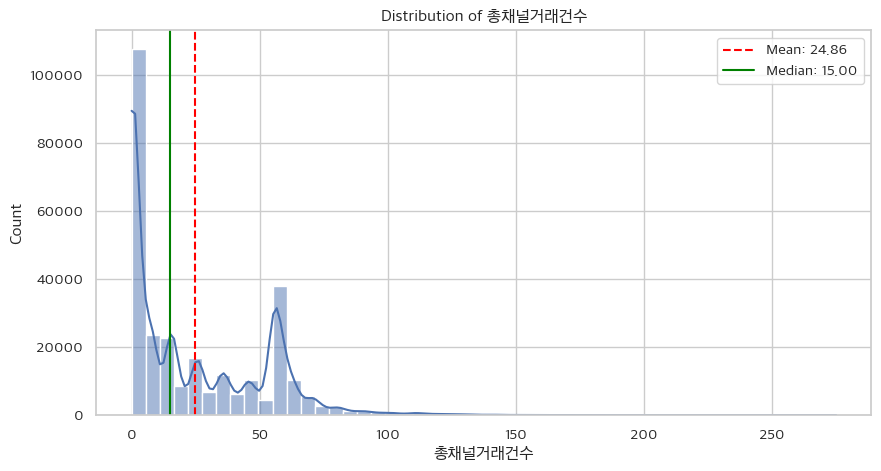

[총채널거래건수_log 통계치]
평균: 2.33 | 중앙값: 2.77 | 최빈값: 0.00


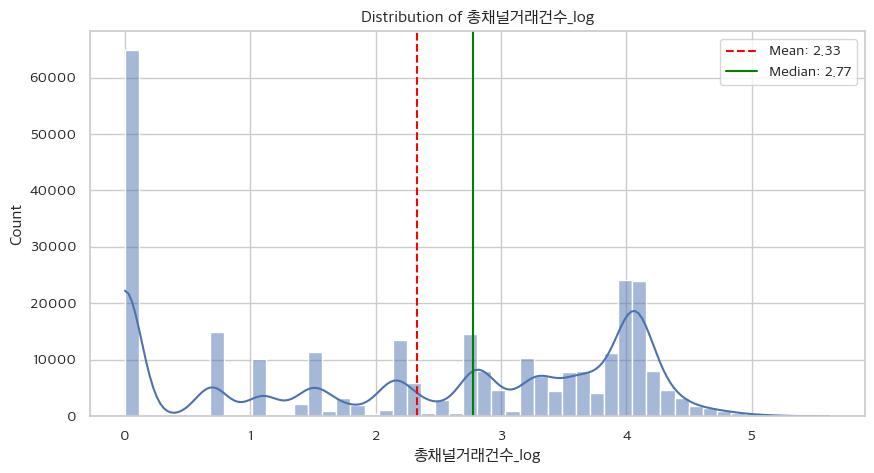

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def check_distribution(df, col):
    # 기초통계량 계산
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] # 최빈값
    
    print(f"[{col} 통계치]")
    print(f"평균: {mean_val:,.2f} | 중앙값: {median_val:,.2f} | 최빈값: {mode_val:,.2f}")
    
    # 히스토그램 시각화
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=50)
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:,.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:,.2f}')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

# 예시: 로그 변환 전후 비교 (총예금잔액)
# 원본 확인
check_distribution(analysis_df2, '총채널거래건수')

# 로그 변환 후 확인
analysis_df2['총채널거래건수_log'] = np.log1p(analysis_df2['총채널거래건수'])
check_distribution(analysis_df2, '총채널거래건수_log')

# 활동성지수(FAI)

In [26]:
def _get_scaler(scaler_type='minmax'):

    if scaler_type == 'minmax':
        return MinMaxScaler()
    if scaler_type == 'standard':
        return StandardScaler()
    raise ValueError("scaler_type은 'minmax' 또는 'standard'만 지원합니다.")

def _scale_series(series, scaler_type='minmax', log_transform=True):
    values = pd.to_numeric(series, errors='coerce').fillna(0).astype(float)

    # 결측치는 기본적으로 0으로 대체한다.
    # 다만 실제 업무에서는 결측과 실제 0이 다를 수 있으므로 해석 시 주의가 필요하다.
    if log_transform:
        values = np.log1p(values.clip(lower=0))
    scaler = _get_scaler(scaler_type)
    scaled = scaler.fit_transform(values.to_frame()).reshape(-1)
    return pd.Series(scaled, index=series.index)

In [27]:
# 1. 활동성 지표(FAI) 구성 변수
# 규모(Size): 로그 O / 빈도(Freq): 로그 O / 다양성: 이미 0~1 (로그 X)
size_vars = ['총예금잔액', '총대출잔액', '총채널거래금액', '총외환금액', '총카드사용금액']
freq_vars = ['총채널거래건수', '총외환거래건수']
diversity_vars = ['다양성점수']

# 2. 수익성 지표(FPI) 구성 변수
# 기여(Contrib): 로그 O / 효율(Eff): 비율형 (로그 X)
contrib_vars = ['예대마진', '추정_비이자수익']
eff_vars = ['자산대비수익률(%)']

In [28]:
# --- [2. 변수별 스케일링 적용 (로그+민맥스 vs 민맥스)] ---

# 활동성: 규모 & 빈도 (로그 O)
for col in size_vars + freq_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 수익성: 기여도 (로그 O)
for col in contrib_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=True)

# 효율성 & 다양성 (로그 X, 이미 비율형이거나 범위가 좁음)
for col in eff_vars + diversity_vars:
    analysis_df2[f'{col}_score'] = _scale_series(analysis_df2[col], scaler_type='minmax', log_transform=False)

# --- [3. 최종 지표 FAI / FPI 합산] ---

# FAI = (규모평균 + 빈도평균 + 다양성점수) / 3
analysis_df2['규모점수'] = analysis_df2[[f'{c}_score' for c in size_vars]].mean(axis=1)
analysis_df2['빈도점수'] = analysis_df2[[f'{c}_score' for c in freq_vars]].mean(axis=1)
# 다양성점수는 이미 점수화된 컬럼 사용
analysis_df2['FAI'] = (analysis_df2['규모점수'] + analysis_df2['빈도점수'] + analysis_df2['다양성점수_score']) / 3

# FPI = (기여평균 + 효율평균) / 2
analysis_df2['수익기여점수'] = analysis_df2[[f'{c}_score' for c in contrib_vars]].mean(axis=1)
analysis_df2['수익효율점수'] = analysis_df2[[f'{c}_score' for c in eff_vars]].mean(axis=1)
analysis_df2['FPI'] = (analysis_df2['수익기여점수'] + analysis_df2['수익효율점수']) / 2

print("FAI, FPI 지표 생성 완료! 🚀")
print(analysis_df2[['FAI', 'FPI']].describe())

FAI, FPI 지표 생성 완료! 🚀
                 FAI            FPI
count  285160.000000  285160.000000
mean        0.373496       0.073997
std         0.124538       0.067315
min         0.000000       0.000000
25%         0.274491       0.014775
50%         0.383726       0.055446
75%         0.478378       0.119912
max         0.806615       0.502367


In [29]:
# FAI(활동성)는 '황금 밸런스': 중앙값(0.38)과 평균(0.37)이 거의 일치해! 이건 로그 변환이 완벽하게 먹혀서 데이터가 아주 예쁘게 펴졌다는 뜻이야. 사분면 그렸을 때 좌우로 시원하게 갈라질 거야.

# FPI(수익성)의 냉혹한 현실: 중앙값이 0.05로 아주 낮지? 이건 일반 고객군 중에서도 실제로 은행에 돈을 벌어다 주는 '수익성' 높은 고객은 정말 소수라는 뜻이야.

# 전략: 그래서 FPI는 0.5점 같은 절대 기준이 아니라, **중앙값(0.0539)**을 기준으로 잘라야 "남들보다 조금이라도 더 벌어다 주는 알짜"를 찾아낼 수 있어!

---

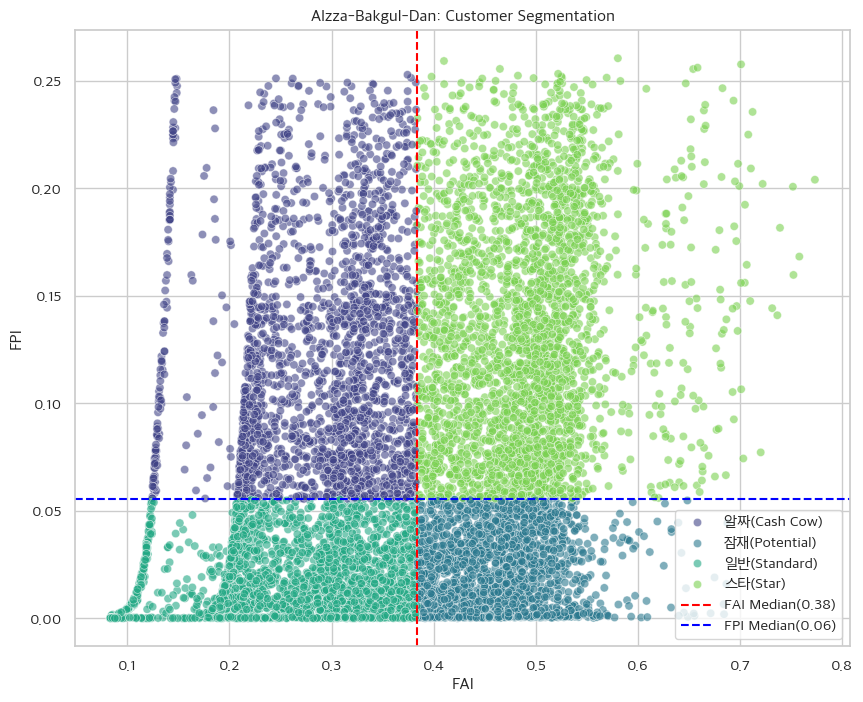

등급
일반(Standard)     83764
스타(Star)         83764
잠재(Potential)    58816
알짜(Cash Cow)     58816
Name: count, dtype: int64


In [30]:
# 1. 중앙값(Median) 기준선 설정
fai_cutoff = analysis_df2['FAI'].median() # 0.3835
fpi_cutoff = analysis_df2['FPI'].median() # 0.0539

# 2. 4사분면 등급 부여 함수
def get_segment(row):
    if row['FAI'] >= fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '스타(Star)'         # 활동도 높고 수익도 높음
    elif row['FAI'] < fai_cutoff and row['FPI'] >= fpi_cutoff:
        return '알짜(Cash Cow)'    # 활동은 적지만 수익은 높음 (주희의 타겟!)
    elif row['FAI'] >= fai_cutoff and row['FPI'] < fpi_cutoff:
        return '잠재(Potential)'   # 활동은 많은데 수익이 낮음 (성장 가능성)
    else:
        return '일반(Standard)'    # 둘 다 낮음

analysis_df2['등급'] = analysis_df2.apply(get_segment, axis=1)

# 3. 사분면 시각화 (Scatter Plot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df2.sample(10000), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)
plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title('Alzza-Bakgul-Dan: Customer Segmentation')
plt.legend()
plt.show()

print(analysis_df2['등급'].value_counts())

In [31]:
# 등급별로 우리가 만든 원본 변수들의 평균을 비교해보자
final_profile = analysis_df2.groupby('등급')[['총예금잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].mean()
final_profile2 = analysis_df2.groupby('등급')[['총예금잔액', '예대마진', '총채널거래건수', 'FAI', 'FPI']].median()

# FPI(수익성) 높은 순으로 정렬해서 확인
print("=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===")
print(final_profile.sort_values(by='FPI', ascending=False))
print("=== 알짜발굴단 등급별 프로파일링 결과 (median) ===")
print(final_profile2.sort_values(by='FPI', ascending=False))

=== 알짜발굴단 등급별 프로파일링 결과 (mean) ===
                    총예금잔액      예대마진    총채널거래건수       FAI       FPI
등급                                                                
스타(Star)        87.168690  4.916085  41.154261  0.489928  0.133249
알짜(Cash Cow)    23.350598  4.290762   4.525529  0.284543  0.122487
잠재(Potential)  146.494495  0.063300  44.084169  0.461765  0.020886
일반(Standard)    24.246804  0.193020   9.331742  0.257547  0.017990
=== 알짜발굴단 등급별 프로파일링 결과 (median) ===
               총예금잔액      예대마진  총채널거래건수       FAI       FPI
등급                                                         
스타(Star)        23.7  3.394920     45.0  0.492403  0.125918
알짜(Cash Cow)     1.3  2.719040      1.0  0.297716  0.110859
잠재(Potential)   30.0  0.194500     46.0  0.459371  0.017543
일반(Standard)     0.6  0.144703      1.0  0.254319  0.013033


In [32]:
cc= analysis_df2[analysis_df2['등급']=='알짜(Cash Cow)']
ccc= analysis_df2[analysis_df2['등급']=='잠재(Potential)']
ccc1= analysis_df2[analysis_df2['등급']=='스타(Star)']

In [33]:
print(cc['법인_고객등급'].value_counts())
print(ccc['법인_고객등급'].value_counts())
print(ccc1['법인_고객등급'].value_counts())

법인_고객등급
우수     26188
최우수    19913
일반     12715
Name: count, dtype: int64
법인_고객등급
우수     26837
일반     16143
최우수    15836
Name: count, dtype: int64
법인_고객등급
최우수    47803
우수     30474
일반      5487
Name: count, dtype: int64


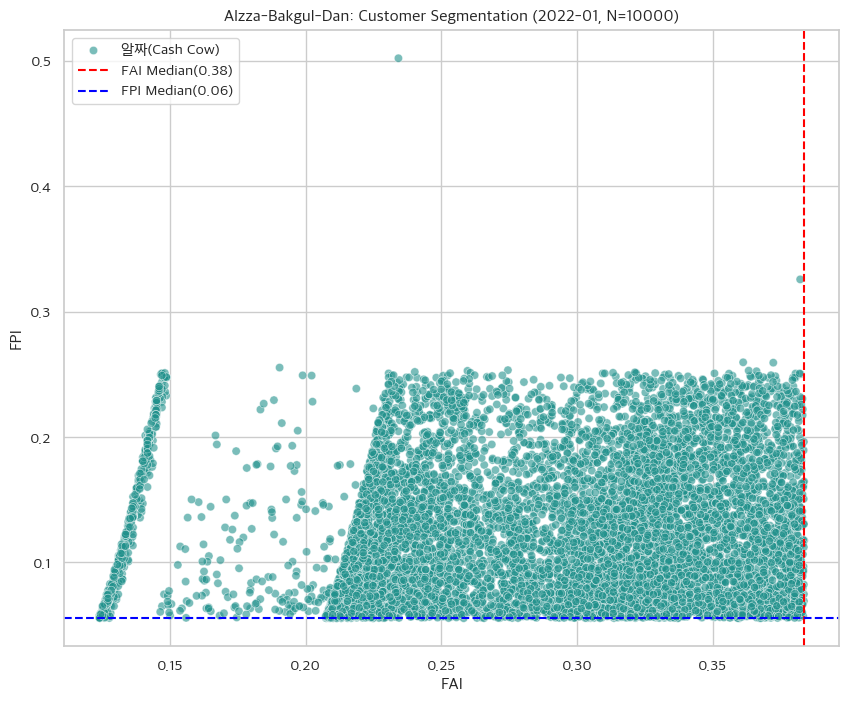

등급
알짜(Cash Cow)    58816
Name: count, dtype: int64


In [34]:
# 샘플링 개수를 데이터 크기에 맞게 자동 조절
sample_size = min(len(cc), 10000)

plt.figure(figsize=(10, 8))
# sample_size 만큼만 추출
sns.scatterplot(data=cc.sample(sample_size), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)

plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title(f'Alzza-Bakgul-Dan: Customer Segmentation (2022-01, N={sample_size})')
plt.legend()
plt.show()

print(cc['등급'].value_counts())

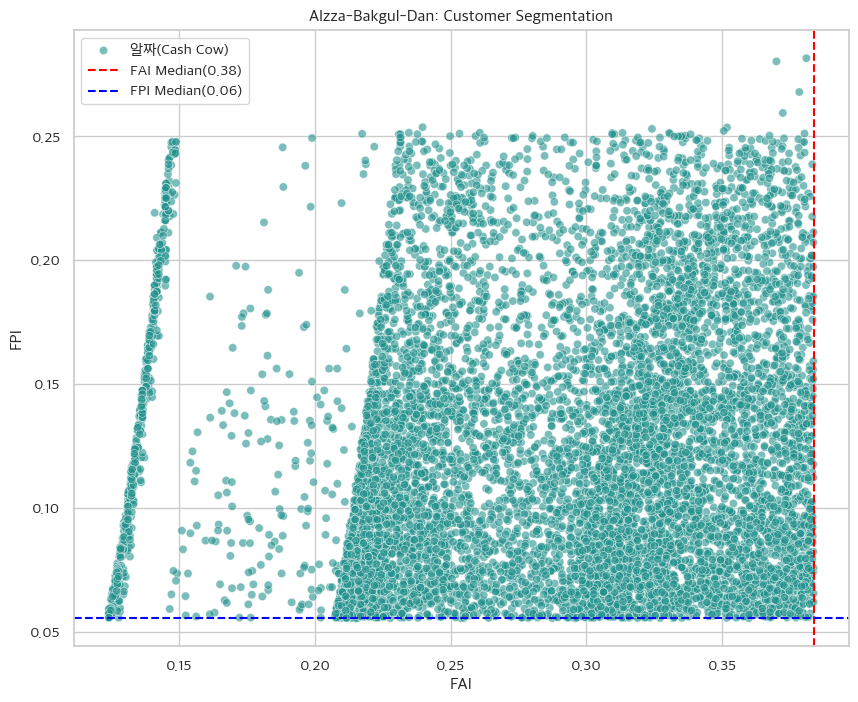

등급
알짜(Cash Cow)    58816
Name: count, dtype: int64


In [35]:
# # 1. 중앙값(Median) 기준선 설정
# fai_cutoff = analysis_df2['FAI'].median() # 0.3835
# fpi_cutoff = analysis_df2['FPI'].median() # 0.0539

# # 2. 4사분면 등급 부여 함수
# def get_segment(row):
#     if row['FAI'] >= fai_cutoff and row['FPI'] >= fpi_cutoff:
#         return '스타(Star)'         # 활동도 높고 수익도 높음
#     elif row['FAI'] < fai_cutoff and row['FPI'] >= fpi_cutoff:
#         return '알짜(Cash Cow)'    # 활동은 적지만 수익은 높음 (주희의 타겟!)
#     elif row['FAI'] >= fai_cutoff and row['FPI'] < fpi_cutoff:
#         return '잠재(Potential)'   # 활동은 많은데 수익이 낮음 (성장 가능성)
#     else:
#         return '일반(Standard)'    # 둘 다 낮음

# analysis_df2['등급'] = analysis_df2.apply(get_segment, axis=1)

# 3. 사분면 시각화 (Scatter Plot)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=cc.sample(10000), x='FAI', y='FPI', hue='등급', 
                palette='viridis', alpha=0.6)
plt.axvline(fai_cutoff, color='red', linestyle='--', label=f'FAI Median({fai_cutoff:.2f})')
plt.axhline(fpi_cutoff, color='blue', linestyle='--', label=f'FPI Median({fpi_cutoff:.2f})')
plt.title('Alzza-Bakgul-Dan: Customer Segmentation')
plt.legend()
plt.show()

print(cc['등급'].value_counts())

------------------------